# EV Charging Infrastructure in Ireland

**Objective :** Analysis on Electric Vehicle charging infrastructure in Ireland.

**Dataset Source**: Downloaded from https://openchargemap.org/ by creating free API key.

## Import the required libraries 

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas import json_normalize
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42

## Dataset Overview

In [2]:
json_path = "EV_Charging_Dataset.json"
with open(json_path, "r", encoding="utf-8") as file:
    raw_data = json.load(file)

print("JSON object type:", type(raw_data))
print("Number of records:", len(raw_data))
print("Top-level keys in first record:")
print(list(raw_data[0].keys()))

JSON object type: <class 'list'>
Number of records: 2348
Top-level keys in first record:
['DataProvider', 'OperatorInfo', 'UsageType', 'StatusType', 'SubmissionStatus', 'IsRecentlyVerified', 'DateLastVerified', 'ID', 'UUID', 'DataProviderID', 'OperatorID', 'UsageTypeID', 'AddressInfo', 'Connections', 'NumberOfPoints', 'StatusTypeID', 'DateLastStatusUpdate', 'DataQualityLevel', 'DateCreated', 'SubmissionStatusTypeID']


In [3]:
raw_df = json_normalize(raw_data)
print("Flattened shape:", raw_df.shape)
raw_df.head(3)

Flattened shape: (2348, 72)


,IsRecentlyVerified,DateLastVerified,ID,UUID,DataProviderID,OperatorID,UsageTypeID,Connections,NumberOfPoints,StatusTypeID,...,AddressInfo.AccessComments,UserComments,AddressInfo.RelatedURL,UsageCost,AddressInfo.ContactTelephone1,OperatorsReference,MetadataValues,AddressInfo.ContactEmail,AddressInfo.ContactTelephone2,DateLastConfirmed
0,True,2026-04-24T14:49:00Z,486774,151643A4-FCA7-4326-B4A6-AB09528E3D84,1,1241.0,6.0,"[{'ID': 819230, 'ConnectionTypeID': 25, 'Conne...",2.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,2026-04-24T10:30:00Z,486771,376A7125-675F-45BB-A850-FF77CF21B637,1,3449.0,4.0,"[{'ID': 819227, 'ConnectionTypeID': 25, 'Conne...",2.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,True,2026-04-22T15:33:00Z,486537,269E6E6B-260B-4732-8058-3BD42B8B381E,1,3578.0,4.0,"[{'ID': 818511, 'ConnectionTypeID': 33, 'Conne...",2.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Shape:", raw_df.shape)
print("Column count:", raw_df.shape[1])
print("Data types:")
print(raw_df.dtypes.value_counts())
print("Missing values in top 15 columns:")
print(raw_df.isna().sum().sort_values(ascending=False).head(15))

Shape: (2348, 72)
Column count: 72
Data types:
object     46
int64      11
float64     9
bool        6
Name: count, dtype: int64
Missing values in top 15 columns:
DateLastConfirmed                2346
AddressInfo.ContactTelephone2    2344
AddressInfo.ContactEmail         2339
MetadataValues                   2337
AddressInfo.RelatedURL           2285
UserComments                     2273
AddressInfo.ContactTelephone1    2270
AddressInfo.AccessComments       2258
GeneralComments                  2220
MediaItems                       2178
UsageCost                        2114
OperatorsReference               1870
OperatorInfo.FaultReportEmail    1861
OperatorInfo.Comments            1809
AddressInfo.AddressLine2         1808
dtype: int64


## Exploratory Data Analysis

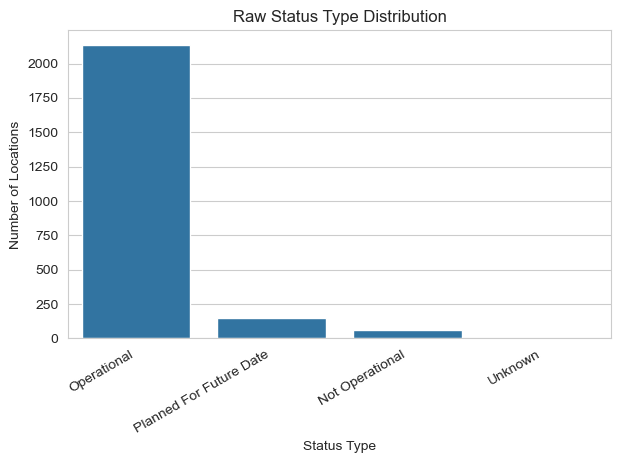

StatusType.Title
Operational                2135
Planned For Future Date     146
Not Operational              59
NaN                           5
Unknown                       3
Name: count, dtype: int64


In [5]:
# Figure B.1
plt.figure(figsize=(7, 4))
sns.countplot(data=raw_df, x="StatusType.Title", order=raw_df["StatusType.Title"].value_counts().index)
plt.title("Raw Status Type Distribution")
plt.xlabel("Status Type")
plt.ylabel("Number of Locations")
plt.xticks(rotation=30, ha="right")
plt.show()

print(raw_df["StatusType.Title"].value_counts(dropna=False))

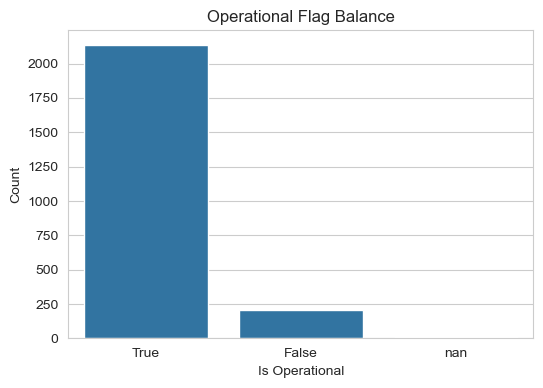

StatusType.IsOperational
True     2135
False     205
NaN         8
Name: count, dtype: int64


In [6]:
# Figure B.2
status_counts = raw_df["StatusType.IsOperational"].value_counts(dropna=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=status_counts.index.astype(str), y=status_counts.values)
plt.title("Operational Flag Balance")
plt.xlabel("Is Operational")
plt.ylabel("Count")
plt.show()

print(status_counts)

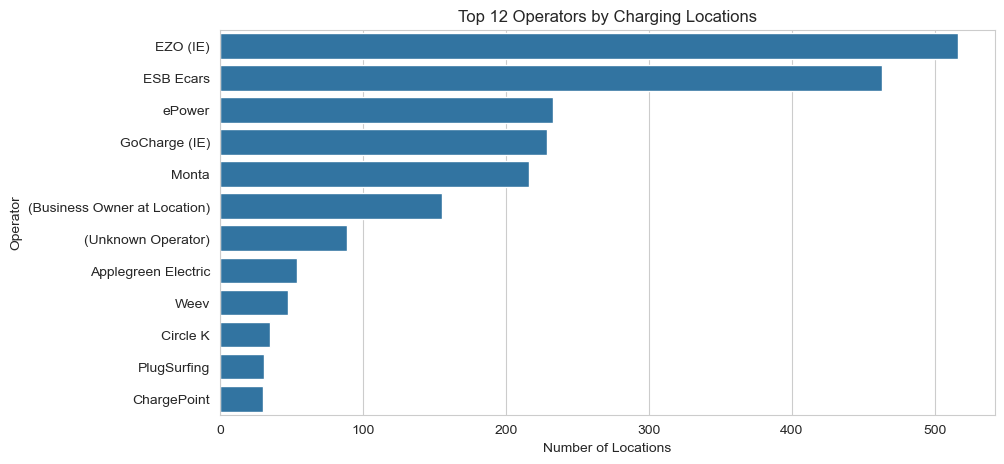

In [7]:
# Figure B.3
top_operators = raw_df["OperatorInfo.Title"].fillna("Unknown").value_counts().head(12)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_operators.values, y=top_operators.index)
plt.title("Top 12 Operators by Charging Locations")
plt.xlabel("Number of Locations")
plt.ylabel("Operator")
plt.show()

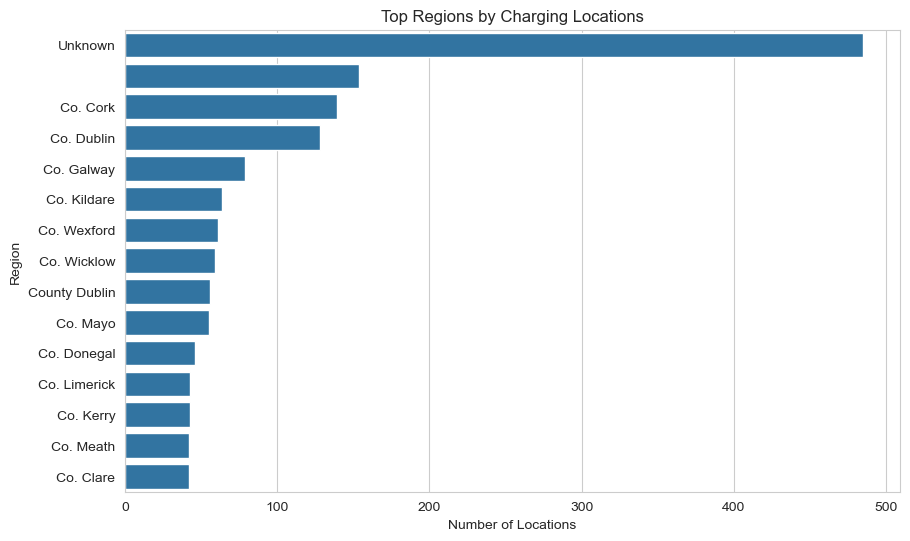

In [8]:
# Figure B.4
top_regions = raw_df["AddressInfo.StateOrProvince"].fillna("Unknown").value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_regions.values, y=top_regions.index)
plt.title("Top Regions by Charging Locations")
plt.xlabel("Number of Locations")
plt.ylabel("Region")
plt.show()

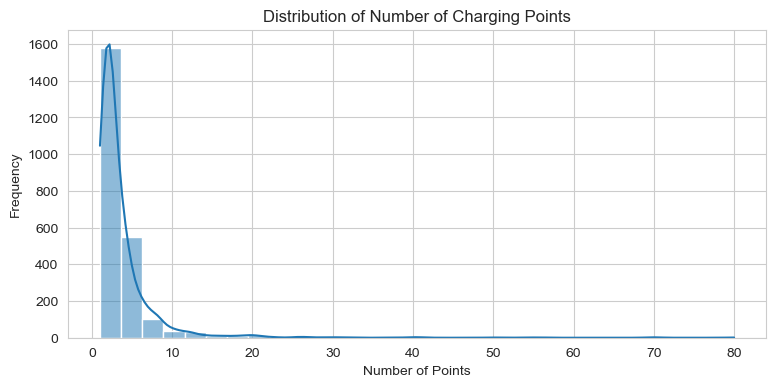

count    2347.000000
mean        3.615680
std         4.662037
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        80.000000
Name: NumberOfPoints, dtype: float64

In [9]:
# Figure B.5
plt.figure(figsize=(9, 4))
sns.histplot(raw_df["NumberOfPoints"].dropna(), bins=30, kde=True)
plt.title("Distribution of Number of Charging Points")
plt.xlabel("Number of Points")
plt.ylabel("Frequency")
plt.show()

raw_df["NumberOfPoints"].describe()

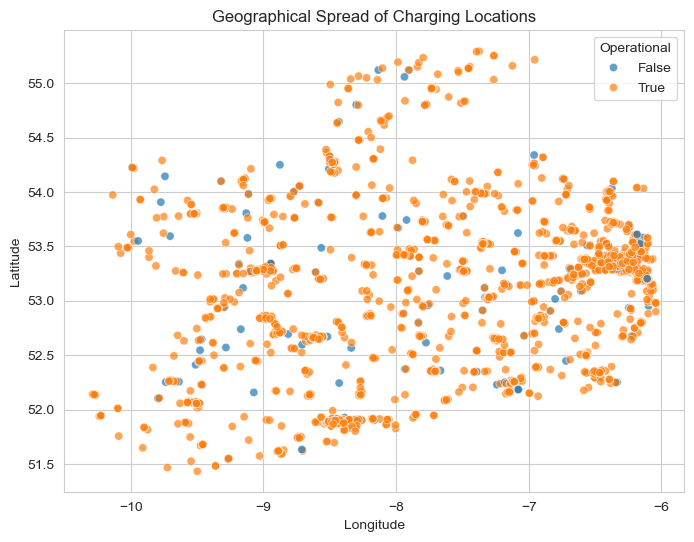

In [10]:
# Figure B.6
map_df = raw_df.dropna(subset=["AddressInfo.Latitude", "AddressInfo.Longitude"]).copy()
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=map_df,
    x="AddressInfo.Longitude",
    y="AddressInfo.Latitude",
    hue="StatusType.IsOperational",
    alpha=0.7
)
plt.title("Geographical Spread of Charging Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Operational")
plt.show()

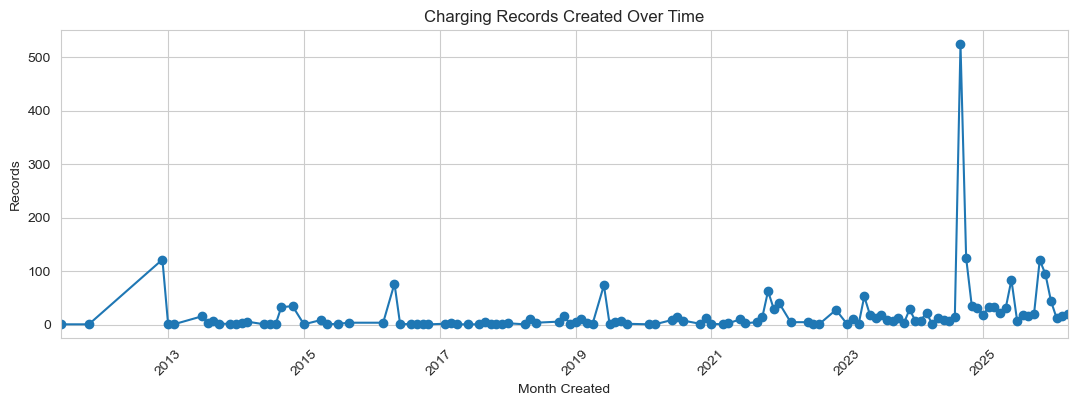

In [11]:
# Figure B.7
created = pd.to_datetime(raw_df["DateCreated"], errors="coerce")
monthly_created = created.dt.to_period("M").value_counts().sort_index()

plt.figure(figsize=(13, 4))
monthly_created.plot(kind="line", marker="o")
plt.title("Charging Records Created Over Time")
plt.xlabel("Month Created")
plt.ylabel("Records")
plt.xticks(rotation=45)
plt.show()

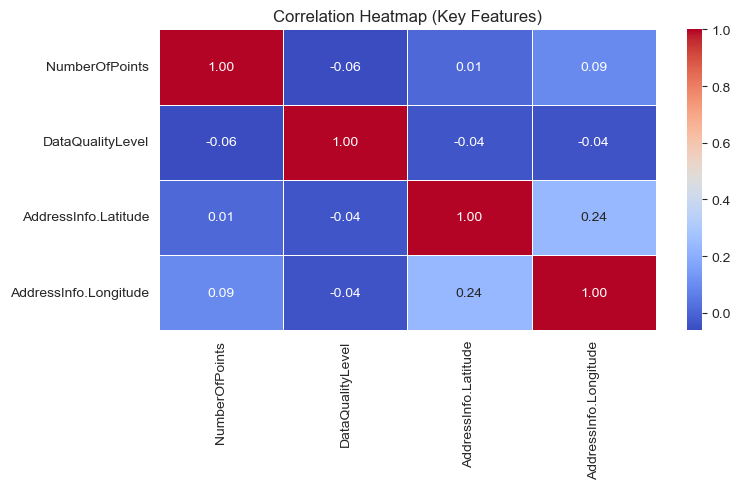

In [12]:
# Figure B.8
plt.figure(figsize=(8,5))
cols = ["NumberOfPoints","DataQualityLevel","AddressInfo.Latitude","AddressInfo.Longitude"]
corr = raw_df[cols].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap (Key Features)")
plt.tight_layout()
plt.show()

## Data Cleaning and Feature Engineering

In [13]:
connection_features = []

for record in raw_data:
    connections = record.get("Connections") or []
    powers = [c.get("PowerKW") for c in connections if c.get("PowerKW") is not None]
    quantities = [c.get("Quantity") for c in connections if c.get("Quantity") is not None]
    current_titles = [((c.get("CurrentType") or {}).get("Title")) for c in connections]
    connector_titles = [((c.get("ConnectionType") or {}).get("Title") or "Unknown") for c in connections]
    fast_flags = [((c.get("Level") or {}).get("IsFastChargeCapable")) for c in connections]

    connection_features.append({
        "connection_count": len(connections),
        "max_power_kw": max(powers) if powers else np.nan,
        "mean_power_kw": np.mean(powers) if powers else np.nan,
        "total_connector_quantity": sum(quantities) if quantities else np.nan,
        "has_dc": int("DC" in current_titles),
        "has_fast_level3": int(True in fast_flags),
        "connection_titles": " | ".join(sorted(set(connector_titles))) if connector_titles else "Unknown"
    })

connection_df = pd.DataFrame(connection_features)
df = pd.concat([raw_df.drop(columns=["Connections"], errors="ignore"), connection_df], axis=1)
print("Shape after connection feature engineering:", df.shape)
df[["connection_count", "max_power_kw", "total_connector_quantity", "has_dc", "has_fast_level3", "connection_titles"]].head()

Shape after connection feature engineering: (2348, 78)


,connection_count,max_power_kw,total_connector_quantity,has_dc,has_fast_level3,connection_titles
0,1,NaN,2.0,0,0,Type 2 (Socket Only)
1,1,22.0,2.0,0,0,Type 2 (Socket Only)
2,1,100.0,2.0,1,1,CCS (Type 2)
3,1,NaN,2.0,1,0,CCS (Type 2)
4,1,NaN,4.0,1,0,CCS (Type 2)


In [14]:
model_df = df[df["StatusType.IsOperational"].notna()].copy()
model_df["target_operational"] = model_df["StatusType.IsOperational"].astype(int)

print(model_df["target_operational"].value_counts())
print("Target rate:", round(model_df["target_operational"].mean(), 4))

target_operational
1    2135
0     205
Name: count, dtype: int64
Target rate: 0.9124


In [15]:
leakage_columns = [
    col for col in model_df.columns
    if col.startswith("StatusType") or "StatusTypeID" in col or col.startswith("SubmissionStatus")
]
leakage_columns += [
    "ID", "UUID", "AddressInfo.ID", "DataProviderID", "OperatorID", "UsageTypeID",
    "SubmissionStatusTypeID", "DateLastStatusUpdate", "DateLastVerified", "DateLastConfirmed"
]
text_or_contact_columns = [
    col for col in model_df.columns
    if any(token in col.lower() for token in [
        "websiteurl", "contactemail", "phone", "comments", "accesscomments", "usercomments",
        "relatedurl", "license", "operatorsreference", "mediaitems", "metadatavalues",
        "addressinfo.title", "addressinfo.addressline", "postcode"
    ])
]
columns_to_drop = sorted(set(leakage_columns + text_or_contact_columns + ["target_operational"]))
X = model_df.drop(columns=columns_to_drop, errors="ignore")
y = model_df["target_operational"]

print("Features after leakage control:", X.shape[1])
print("Rows used for modelling:", X.shape[0])
print("Dropped leakage/noise columns:", len(columns_to_drop))
print(columns_to_drop)

Features after leakage control: 39
Rows used for modelling: 2340
Dropped leakage/noise columns: 40
['AddressInfo.AccessComments', 'AddressInfo.AddressLine1', 'AddressInfo.AddressLine2', 'AddressInfo.ContactEmail', 'AddressInfo.ContactTelephone1', 'AddressInfo.ContactTelephone2', 'AddressInfo.ID', 'AddressInfo.Postcode', 'AddressInfo.RelatedURL', 'AddressInfo.Title', 'DataProvider.IsOpenDataLicensed', 'DataProvider.License', 'DataProvider.WebsiteURL', 'DataProviderID', 'DateLastConfirmed', 'DateLastStatusUpdate', 'DateLastVerified', 'GeneralComments', 'ID', 'MediaItems', 'MetadataValues', 'OperatorID', 'OperatorInfo.Comments', 'OperatorInfo.ContactEmail', 'OperatorInfo.PhonePrimaryContact', 'OperatorInfo.WebsiteURL', 'OperatorsReference', 'StatusType.ID', 'StatusType.IsOperational', 'StatusType.IsUserSelectable', 'StatusType.Title', 'StatusTypeID', 'SubmissionStatus.ID', 'SubmissionStatus.IsLive', 'SubmissionStatus.Title', 'SubmissionStatusTypeID', 'UUID', 'UsageTypeID', 'UserComments',

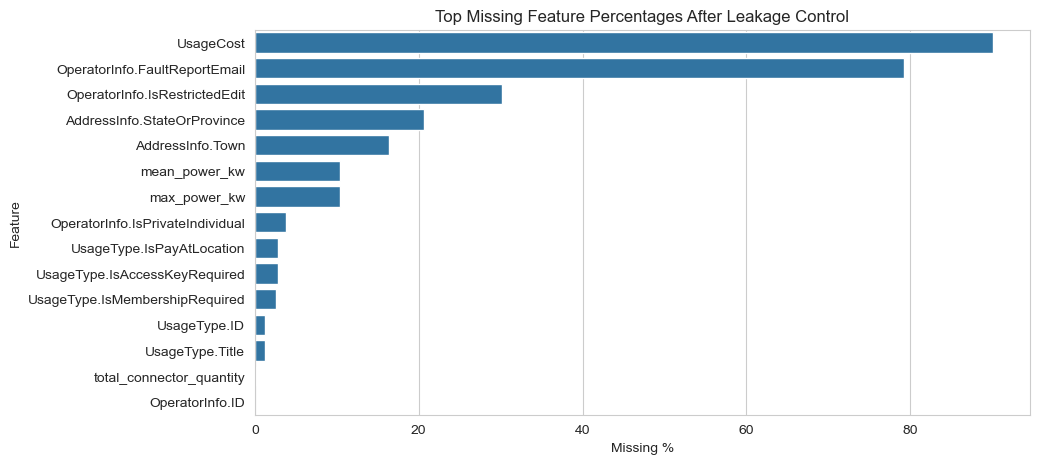

UsageCost                           90.085470
OperatorInfo.FaultReportEmail       79.273504
OperatorInfo.IsRestrictedEdit       30.213675
AddressInfo.StateOrProvince         20.598291
AddressInfo.Town                    16.367521
mean_power_kw                       10.384615
max_power_kw                        10.384615
OperatorInfo.IsPrivateIndividual     3.846154
UsageType.IsPayAtLocation            2.863248
UsageType.IsAccessKeyRequired        2.863248
UsageType.IsMembershipRequired       2.606838
UsageType.ID                         1.282051
UsageType.Title                      1.282051
total_connector_quantity             0.085470
OperatorInfo.ID                      0.042735
dtype: float64

In [16]:
# Figure B.9
missing_after = X.isna().mean().sort_values(ascending=False).head(15) * 100
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_after.values, y=missing_after.index)
plt.title("Top Missing Feature Percentages After Leakage Control")
plt.xlabel("Missing %")
plt.ylabel("Feature")
plt.show()

missing_after

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Train target balance:", y_train.value_counts(normalize=True))
print("Test target balance:", y_test.value_counts(normalize=True))

Training shape: (1872, 39)
Testing shape: (468, 39)
Train target balance: target_operational
1    0.912393
0    0.087607
Name: proportion, dtype: float64
Test target balance: target_operational
1    0.912393
0    0.087607
Name: proportion, dtype: float64


In [18]:
numeric_features = X_train.select_dtypes(exclude="object").columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 21
Categorical features: 18


In [19]:
results = []

def evaluate_model(name, fitted_model, X_test, y_test):
    preds = fitted_model.predict(X_test)
    probs = fitted_model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }
    results.append(metrics)

    print(f"{name} Classification Report")
    print(classification_report(y_test, preds, target_names=["Not Operational", "Operational"]))

    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["Not Operational", "Operational"],
        cmap="Blues",
        values_format="d"
    )
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return metrics

## Model 1: Logistic Regression

In [20]:
print("Available variables:")
print([name for name in globals() if "pipe" in name.lower() or "model" in name.lower()])

Available variables:
['Pipeline', 'model_df', 'evaluate_model']


Candidate: {'C': 0.3, 'class_weight': 'balanced'} Validation accuracy: 0.9707
Candidate: {'C': 1.0, 'class_weight': 'balanced'} Validation accuracy: 0.9813
Candidate: {'C': 3.0, 'class_weight': 'balanced'} Validation accuracy: 0.976
Logistic Regression validation accuracy: 0.9813
Logistic Regression params: {'C': 1.0, 'class_weight': 'balanced'}
Logistic Regression Classification Report
                 precision    recall  f1-score   support

Not Operational       0.77      0.88      0.82        41
    Operational       0.99      0.97      0.98       427

       accuracy                           0.97       468
      macro avg       0.88      0.93      0.90       468
   weighted avg       0.97      0.97      0.97       468



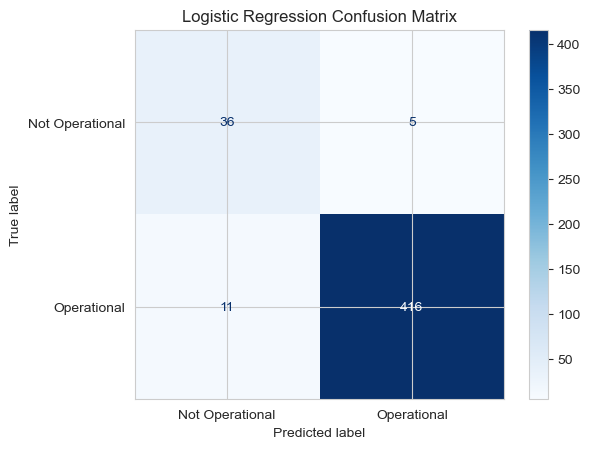

In [21]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

lr_candidates = [
    {"C": 0.3, "class_weight": "balanced"},
    {"C": 1.0, "class_weight": "balanced"},
    {"C": 3.0, "class_weight": "balanced"}
]

best_lr_score = -1
best_lr_params = None
best_lr_model = None

for params in lr_candidates:
    candidate = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE, **params))
    ])
    candidate.fit(X_subtrain, y_subtrain)
    val_pred = candidate.predict(X_val)
    val_score = accuracy_score(y_val, val_pred)
    print("Candidate:", params, "Validation accuracy:", round(val_score, 4))

    if val_score > best_lr_score:
        best_lr_score = val_score
        best_lr_params = params
        best_lr_model = candidate

# Refit best configuration on the full training set before final testing
final_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE, **best_lr_params))
])
final_lr.fit(X_train, y_train)

print("Logistic Regression validation accuracy:", round(best_lr_score, 4))
print("Logistic Regression params:", best_lr_params)
lr_metrics = evaluate_model("Logistic Regression", final_lr, X_test, y_test)

# Figure B.10

## Model 2: Random Forest Classification

Candidate: {'n_estimators': 250, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'} Validation accuracy: 0.9707
Candidate: {'n_estimators': 300, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt'} Validation accuracy: 0.9707
Candidate: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'} Validation accuracy: 0.984
Random Forest validation accuracy: 0.984
Random Forest params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Random Forest Classification Report
                 precision    recall  f1-score   support

Not Operational       0.89      0.83      0.86        41
    Operational       0.98      0.99      0.99       427

       accuracy                           0.98       468
      macro avg       0.94      0.91      0.92       468
   weighted avg       0.98      0.98      0.98       468



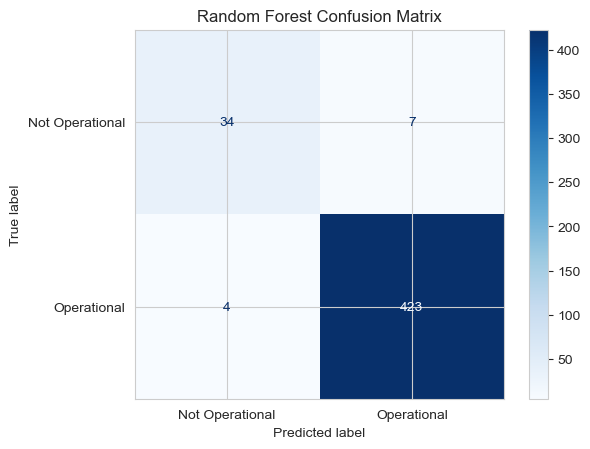

In [22]:
rf_candidates = [
    {"n_estimators": 250, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 18, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"}
]

best_rf_score = -1
best_rf_params = None

for params in rf_candidates:
    candidate = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            n_jobs=-1,
            **params
        ))
    ])
    candidate.fit(X_subtrain, y_subtrain)
    val_pred = candidate.predict(X_val)
    val_score = accuracy_score(y_val, val_pred)
    print("Candidate:", params, "Validation accuracy:", round(val_score, 4))

    if val_score > best_rf_score:
        best_rf_score = val_score
        best_rf_params = params

# Refit best configuration on the full training set before final testing
final_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1,
        **best_rf_params
    ))
])
final_rf.fit(X_train, y_train)

print("Random Forest validation accuracy:", round(best_rf_score, 4))
print("Random Forest params:", best_rf_params)
rf_metrics = evaluate_model("Random Forest", final_rf, X_test, y_test)


#Figure B.11

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv_scores = cross_val_score(
    final_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    final_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Mean CV Accuracy": [log_cv_scores.mean(), rf_cv_scores.mean()],
    "CV Std": [log_cv_scores.std(), rf_cv_scores.std()]
})

display(cv_results)

,Model,Mean CV Accuracy,CV Std
0,Logistic Regression,0.968482,0.009005
1,Random Forest,0.978093,0.009016


## Final Model Comparison

In [24]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.976496,0.983721,0.990632,0.987165,0.967784
0,Logistic Regression,0.965812,0.988124,0.974239,0.981132,0.967384


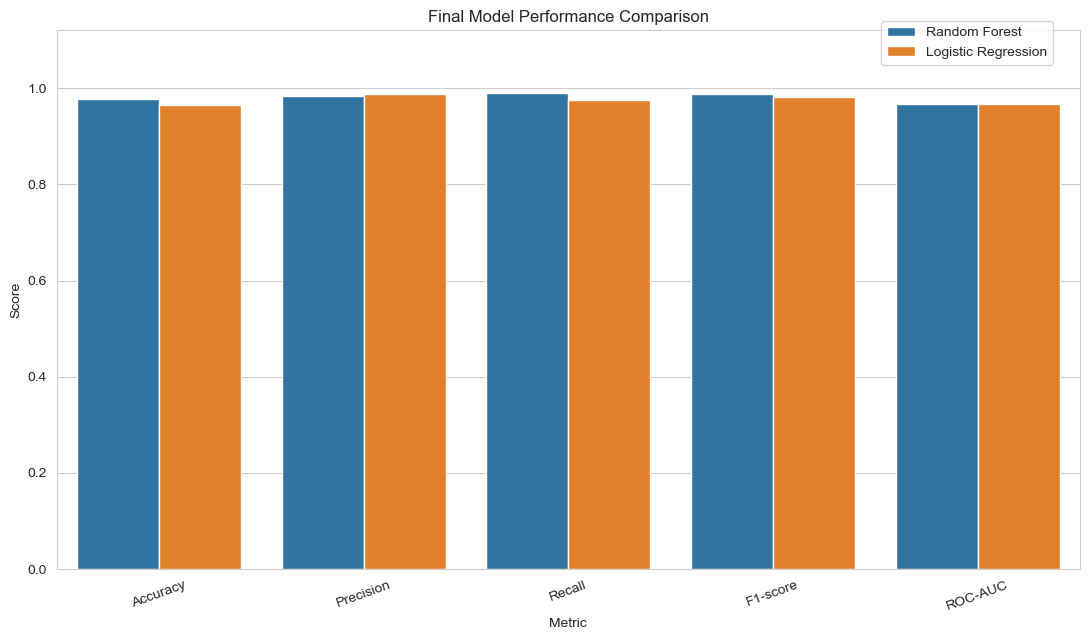

In [25]:
# Figure B.12
metric_plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(11, 6.5))
sns.barplot(data=metric_plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.12)
plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="upper right", bbox_to_anchor=(0.98, 1.03), frameon=True)
plt.tight_layout()
plt.show()